In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import utils
import storm_dates
import pre_processing
import constants
import matplotlib.dates as mdates
from IPython.display import display, HTML

display(HTML("<style>.container { width:100% !important; }</style>"))

/mnt/data/symbolic-regression-dst-public-repo/.venv/lib/python3.12/site-packages/spacepy/time.py:2448: UserWarning: Leapseconds may be out of date. Use spacepy.toolbox.update(leapsecs=True)
  _read_leaps()


In [2]:
relevant_columns = ['Bz', 'Vp', 'Np', 'T', 'Bmag']

In [ ]:
ace_columns = ['Bmag', 'Bx', 'By', 'Bz','Vp', 'Np', 'T']

dst_kyoto = utils.read_iaga_file('./data/dst-kyoto.txt', columns = ["DATE", "TIME", "DOY", "DST"])
dst_kyoto = dst_kyoto[~dst_kyoto.index.duplicated(keep='first')]

ace_imf = utils.read_data('./data/all_timeline', pattern_to_read=['csv', 'ace_imf_1h_'], print_info = True, return_separated = False)
ace_imf.columns = ['Bmag', 'Bx', 'By', 'Bz']
ace_imf = ace_imf[~ace_imf.index.duplicated(keep='first')]

ace_swepam = utils.read_data('./data/all_timeline', pattern_to_read=['csv', 'ace_swepam_1h_'], print_info = True, return_separated = False)                          
ace_swepam.columns = ['Vx', 'Vy', 'Vz', 'Vp', 'Np', 'T']
ace_swepam = ace_swepam.loc[:, ('Vp', 'Np', 'T')]
ace_swepam = ace_swepam[~ace_swepam.index.duplicated(keep='first')]
    
ace_data = ace_imf.join(ace_swepam)

all_data = ace_data.join(dst_kyoto['DST'])

all_data["E_Field"] = -all_data["Vp"] * all_data["Bz"] * 1e-3  # Convective electric field in mV/m
all_data["P_dyn"] = 1.6726e-6 * all_data["Np"] * (all_data["Vp"] ** 2)  # Dynamic pressure

Reading from file ./data/all_timeline/ace_imf_1h_1998.csv
Reading from file ./data/all_timeline/ace_imf_1h_1999.csv
Reading from file ./data/all_timeline/ace_imf_1h_2000.csv
Reading from file ./data/all_timeline/ace_imf_1h_2001.csv
Reading from file ./data/all_timeline/ace_imf_1h_2002.csv
Reading from file ./data/all_timeline/ace_imf_1h_2003.csv
Reading from file ./data/all_timeline/ace_imf_1h_2004.csv
Reading from file ./data/all_timeline/ace_imf_1h_2005.csv
Reading from file ./data/all_timeline/ace_imf_1h_2006.csv
Reading from file ./data/all_timeline/ace_imf_1h_2007.csv
Reading from file ./data/all_timeline/ace_imf_1h_2008.csv
Reading from file ./data/all_timeline/ace_imf_1h_2009.csv
Reading from file ./data/all_timeline/ace_imf_1h_2010.csv
Reading from file ./data/all_timeline/ace_imf_1h_2011.csv
Reading from file ./data/all_timeline/ace_imf_1h_2012.csv
Reading from file ./data/all_timeline/ace_imf_1h_2013.csv
Reading from file ./data/all_timeline/ace_imf_1h_2014.csv
Reading from f

In [4]:
def plot_storm(dst_kyoto, storm, col, sd, ed, storm_index):
    
    fig, ax = plt.subplots(1, 1, figsize = (15, 5))
    l1, = ax.plot(dst_kyoto[sd:ed].index, dst_kyoto[sd:ed]['DST'].values, label = 'Dst (1 hour data)', color = 'red')

    
    lines = [l1]

    if col is not None:
        
        if storm[col].isna().sum() == len(storm[col]):
            l7 = ax.fill_between(
                all_data[sd:ed].index,
                all_data[sd:ed][col].min(),
                all_data[sd:ed][col].max(),
                #where = storm[col].isna(),
                color = 'magenta',
                alpha = 0.1,
                hatch = 'X',
                label = f'Missing {col}'
            )
            
            lines.extend([l7])
            
        else:
    
            twin = ax.twinx()
            l5, = twin.plot(storm.index, storm[col], label = f'{col}', color = 'orange', linestyle='--')
            twin.set_ylabel(f'{col}')        

            l6 = twin.fill_between(
                storm.index,
                storm[col].min(),
                storm[col].max(),
                where = storm[col].isna(),
                color = 'magenta',
                alpha = 0.1,
                hatch = 'X',
                label = f'Missing {col}'
            )

            lines.extend([l5, l6])

            twin.set_ylim(storm[col].min(), storm[col].max())

    labels = [l.get_label() for l in lines]
    
    ax.grid(True)
    ax.set_ylabel('Disturbance (nT)')
    leg = ax.legend(
        lines,
        labels,
        bbox_to_anchor=(0.5, 1.25),
        loc="upper center",
        ncol=3,
        fancybox=True,
        prop={"size": 12},
        edgecolor="black",
        facecolor="none",
    )

    ax.set_xlim(sd, ed)        
    ax.set_xlabel('Date')
    ax.set_title(f'{col} with [{storm[col].isna().sum()}/{len(storm)}] ({storm[col].isna().sum() / len(storm[col]) * 100:.3f}%) missing values for storm {storm_index} from {sd.strftime("%Y-%B-%d")} to {ed.strftime("%Y-%B-%d")}')

    plt.show();
    

There are ACE missing values in test storm 54 from 2017 September 26 to 2017 October 04
Np missing 14 values (7.254%)


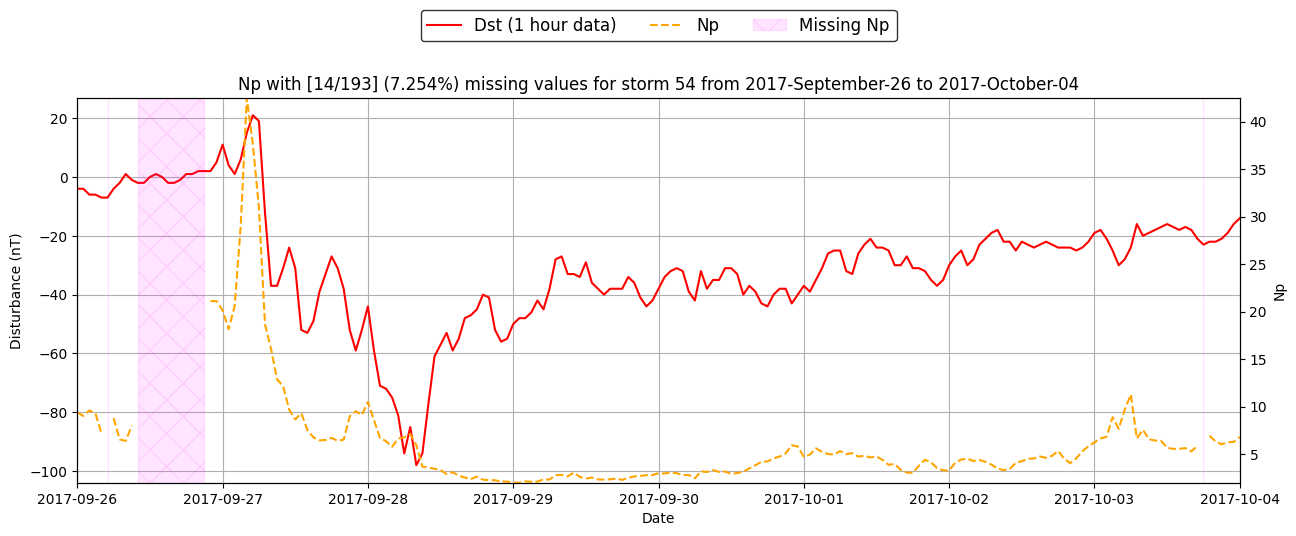

There are ACE missing values in test storm 55 from 2018 August 24 to 2018 September 01
Np missing 2 values (1.036%)


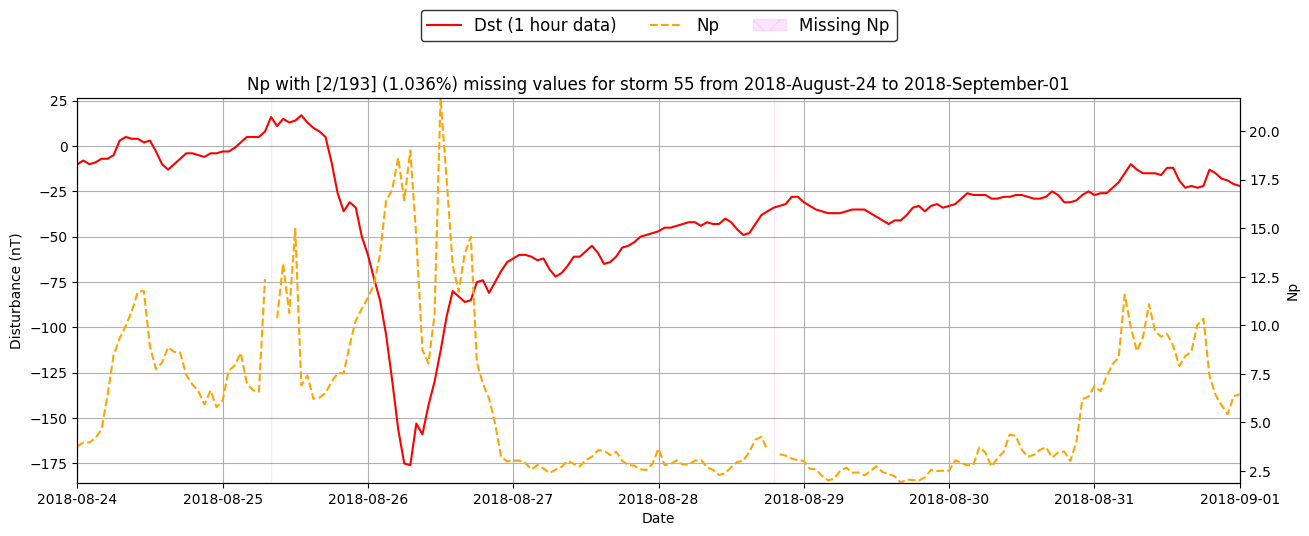

There are ACE missing values in test storm 56 from 2021 November 02 to 2021 November 10
Np missing 173 values (89.637%)


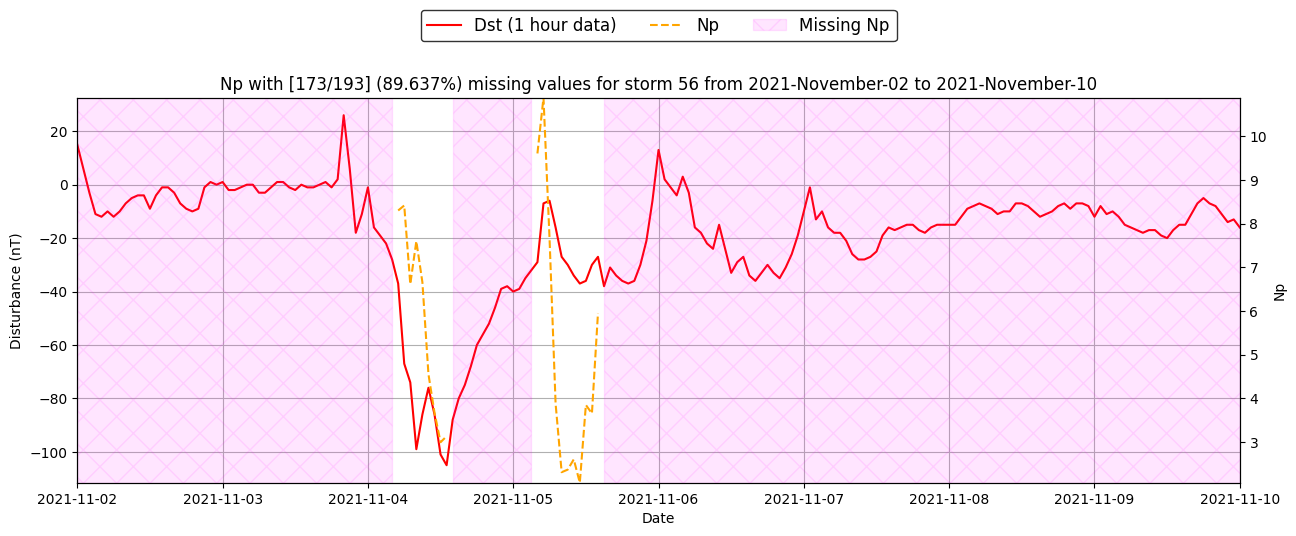

There are ACE missing values in test storm 57 from 2022 January 12 to 2022 January 20
Np missing 12 values (6.218%)


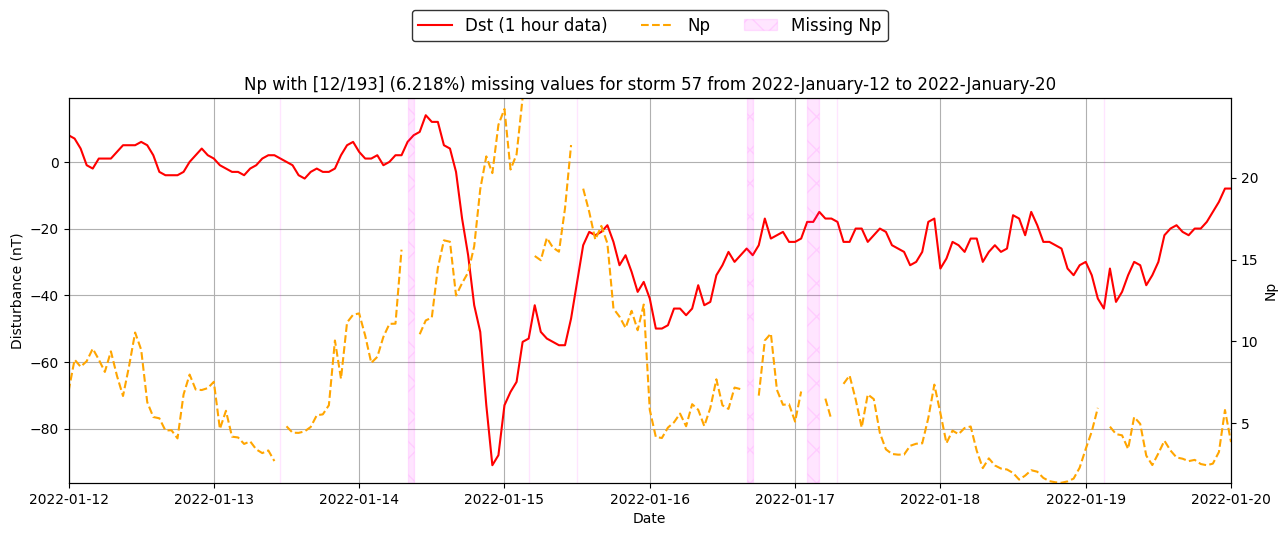

There are ACE missing values in test storm 58 from 2022 November 05 to 2022 November 13
Np missing 88 values (45.596%)


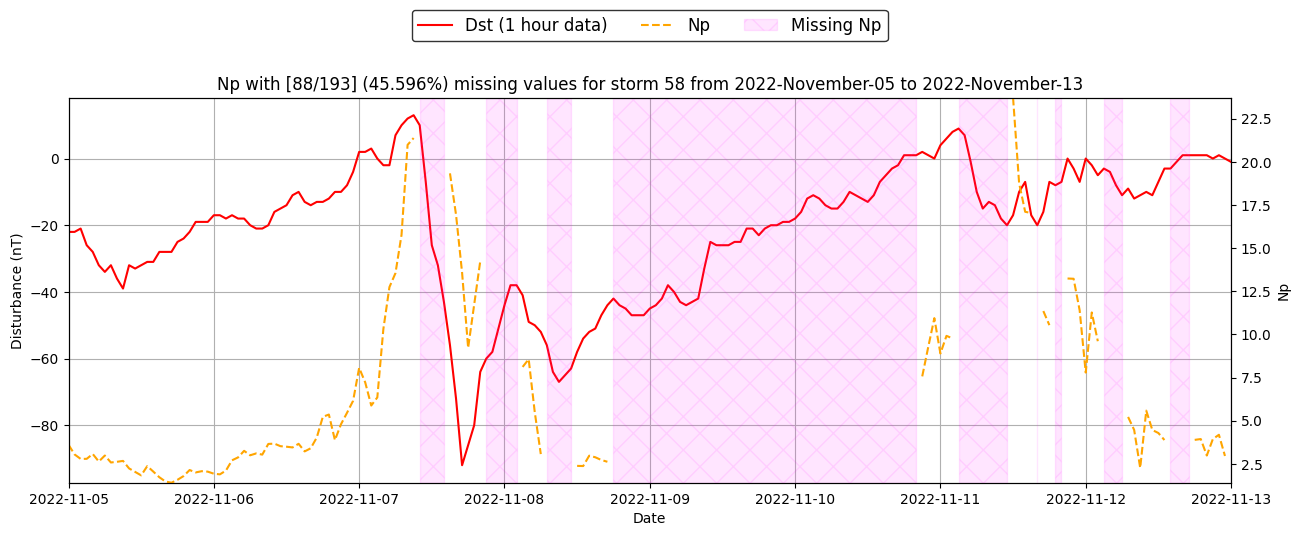

There are ACE missing values in test storm 59 from 2023 February 25 to 2023 March 06
Np missing 194 values (89.401%)


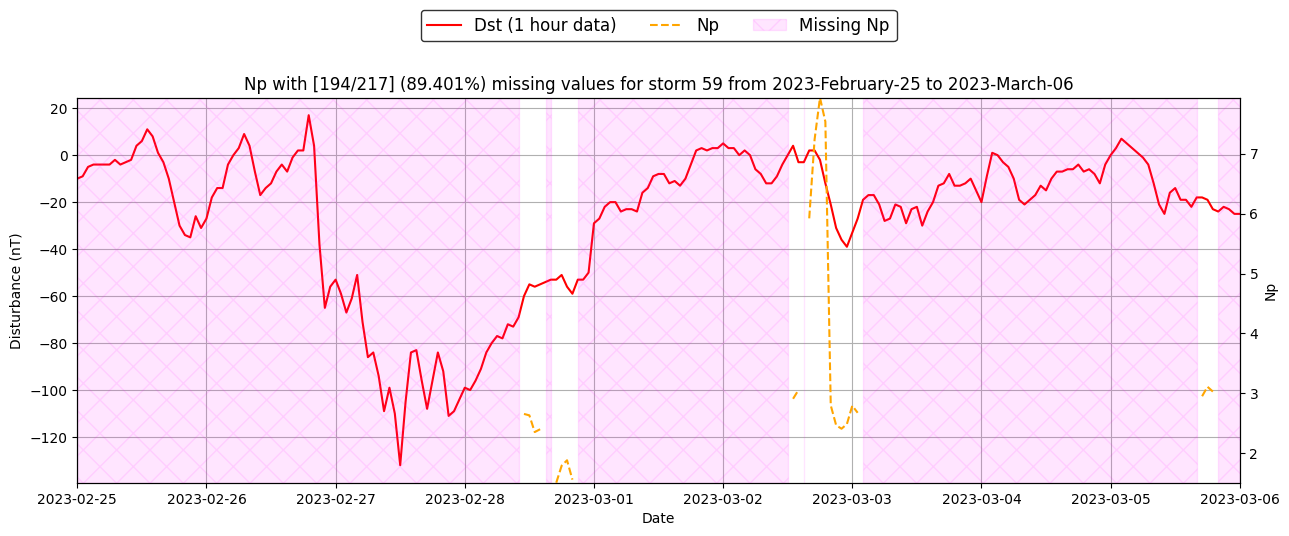

There are ACE missing values in test storm 60 from 2023 March 21 to 2023 March 30
Np missing 196 values (90.323%)


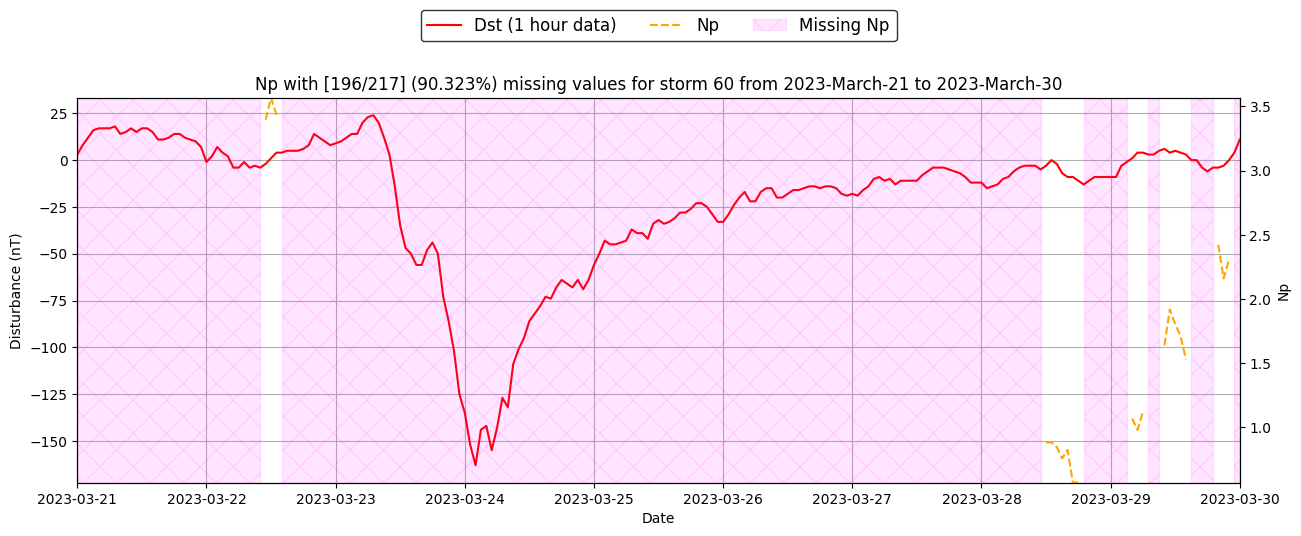

There are ACE missing values in test storm 61 from 2023 April 21 to 2023 April 30
Np missing 126 values (58.065%)


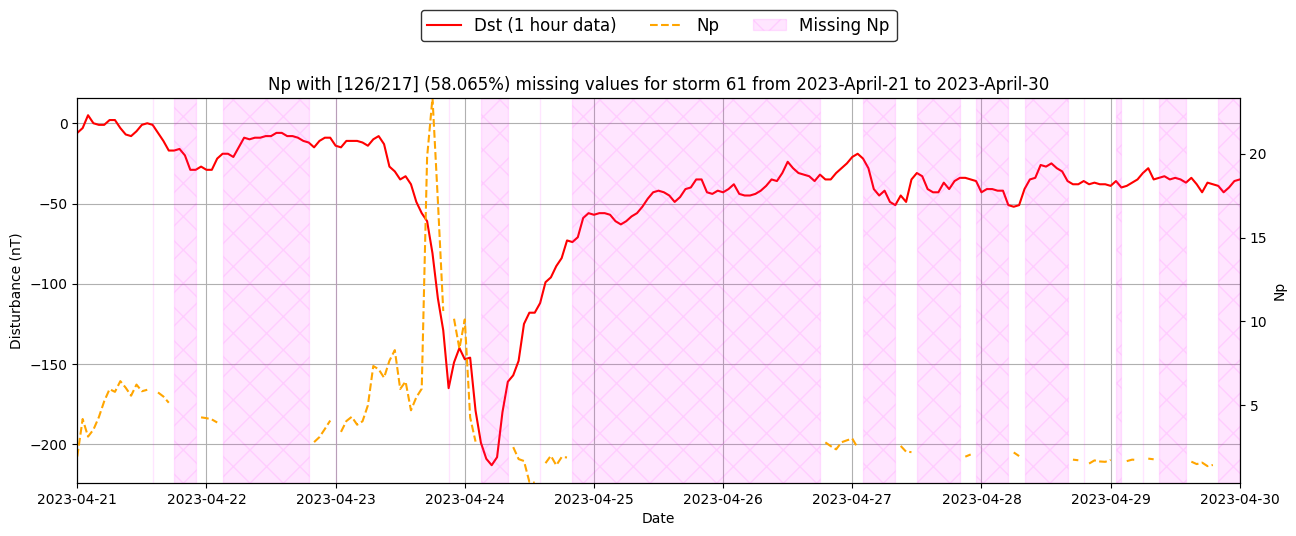

There are ACE missing values in test storm 62 from 2023 August 03 to 2023 August 11
Np missing 132 values (68.394%)


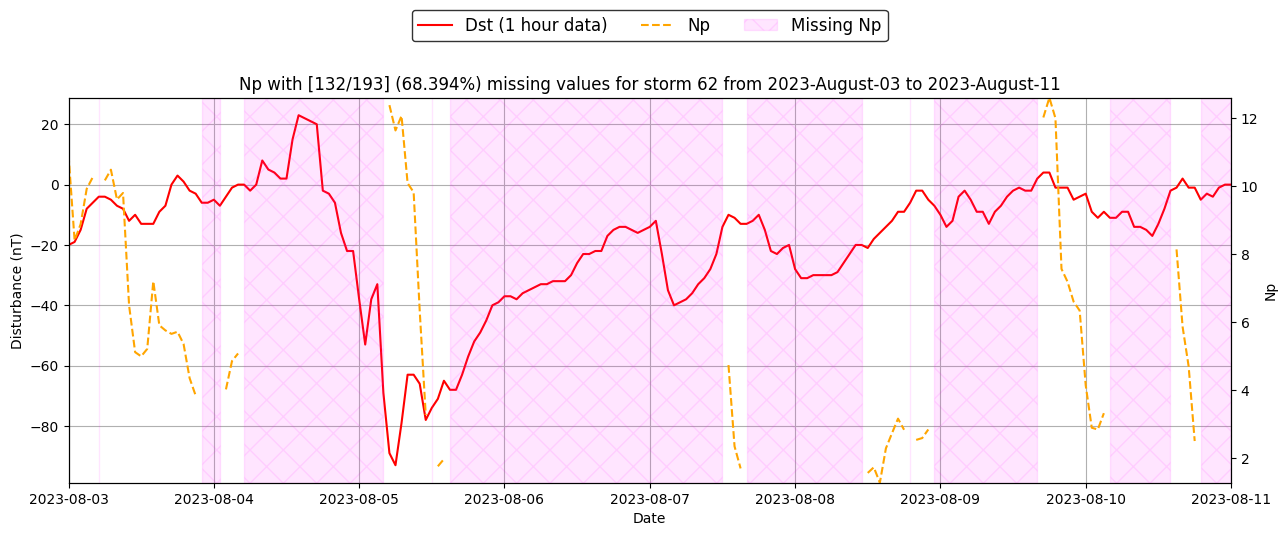

There are ACE missing values in test storm 63 from 2023 November 03 to 2023 November 12
Np missing 65 values (29.954%)


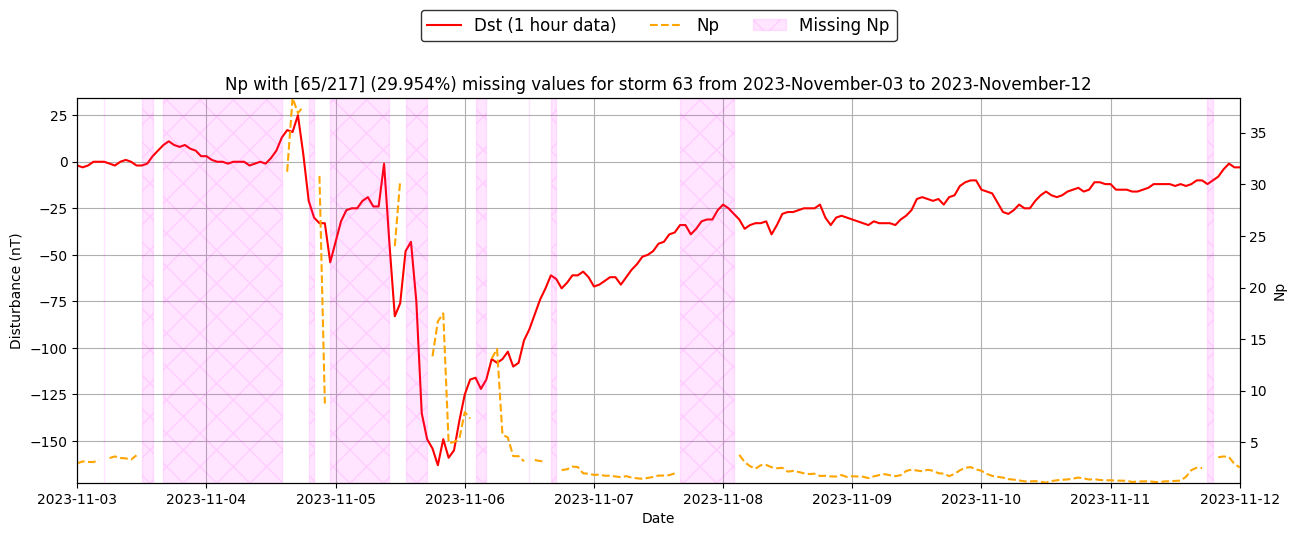

There are ACE missing values in test storm 64 from 2023 November 23 to 2023 December 08
Np missing 168 values (46.537%)


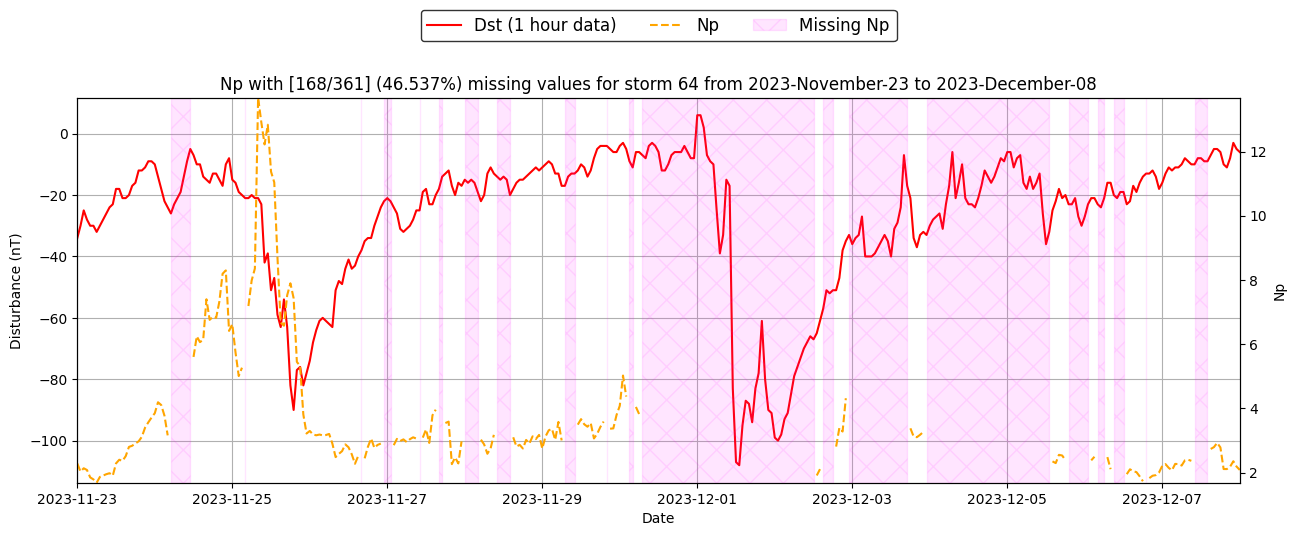

There are ACE missing values in test storm 65 from 2024 March 01 to 2024 March 09
Np missing 115 values (59.585%)


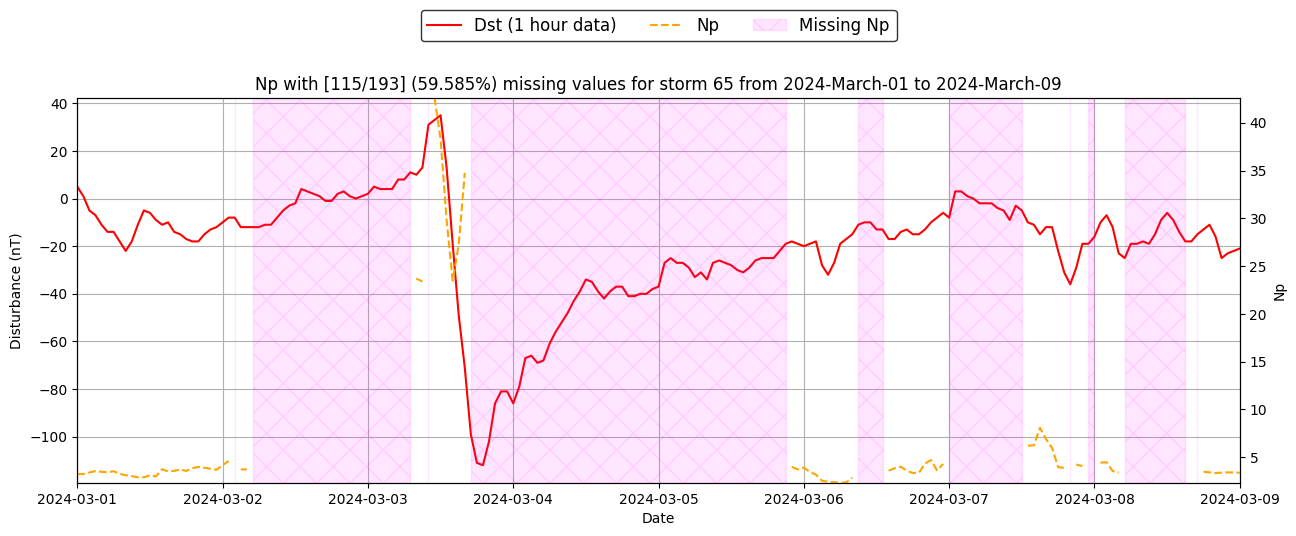

There are ACE missing values in test storm 66 from 2024 March 22 to 2024 March 30
Np missing 118 values (61.140%)


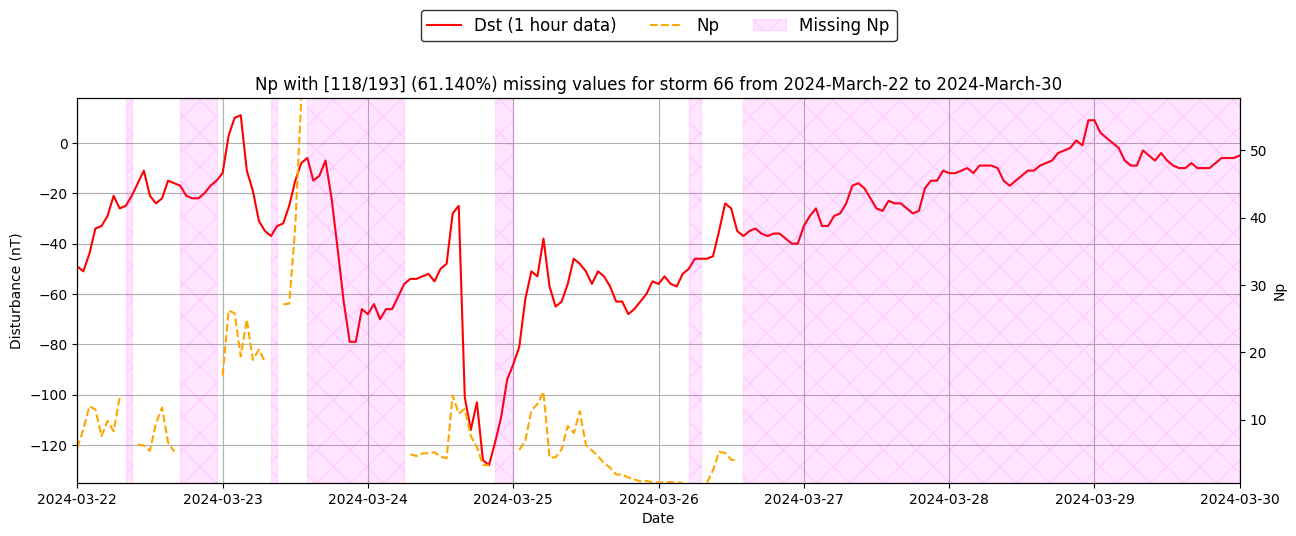

There are ACE missing values in test storm 67 from 2024 April 17 to 2024 April 25
Np missing 175 values (90.674%)


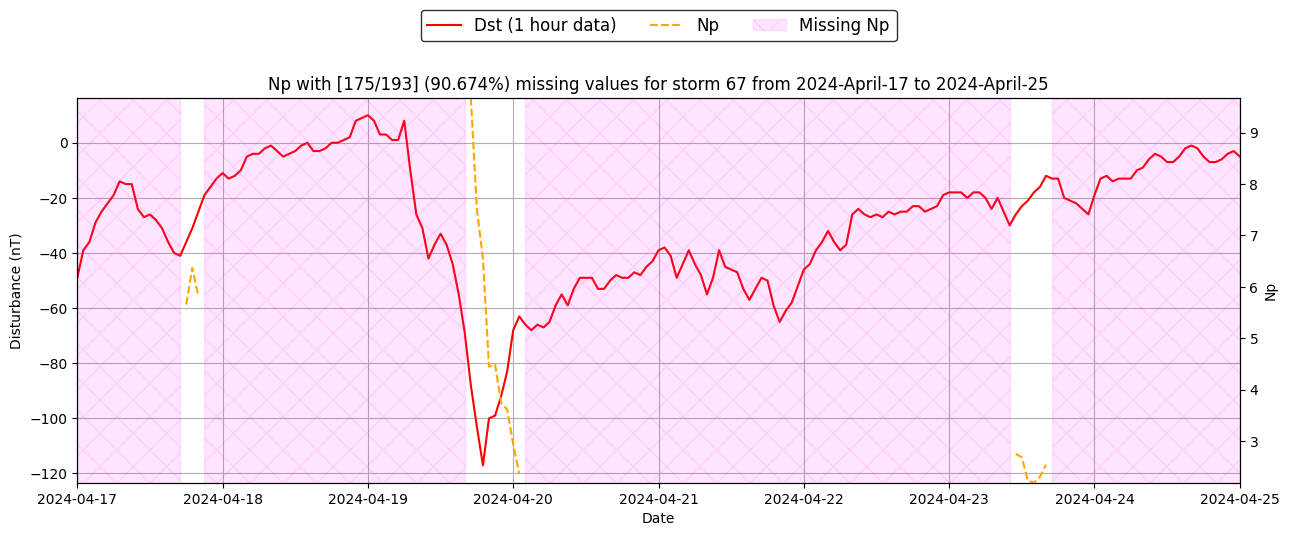

There are ACE missing values in test storm 68 from 2024 May 09 to 2024 May 14
Np missing 13 values (10.744%)


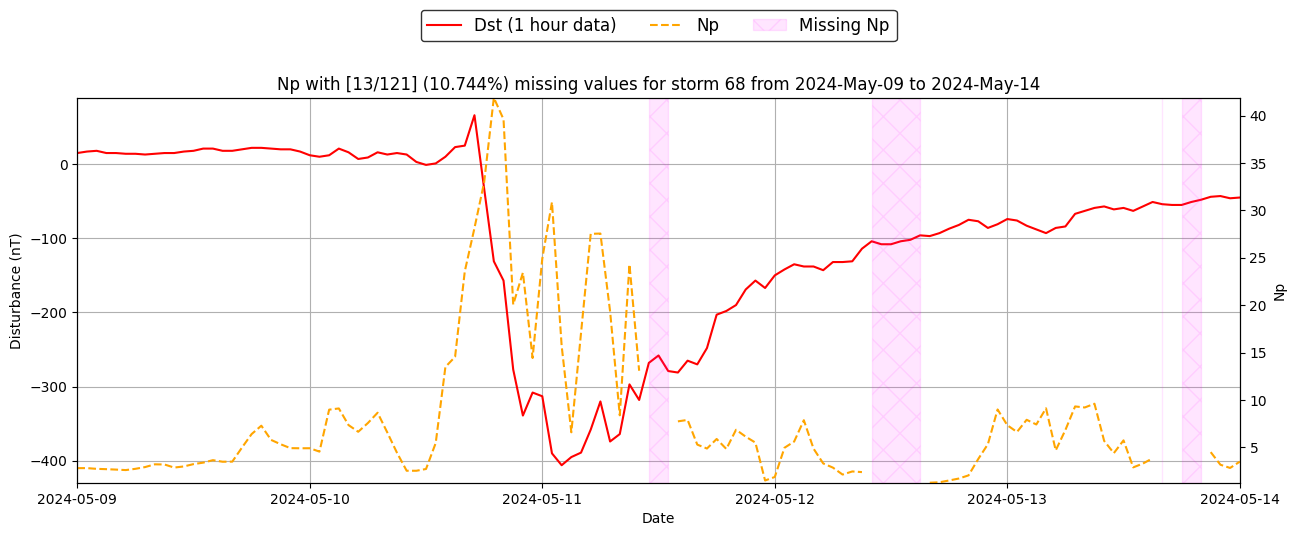

There are ACE missing values in test storm 69 from 2024 June 26 to 2024 July 04
Vp missing 193 values (100.000%)


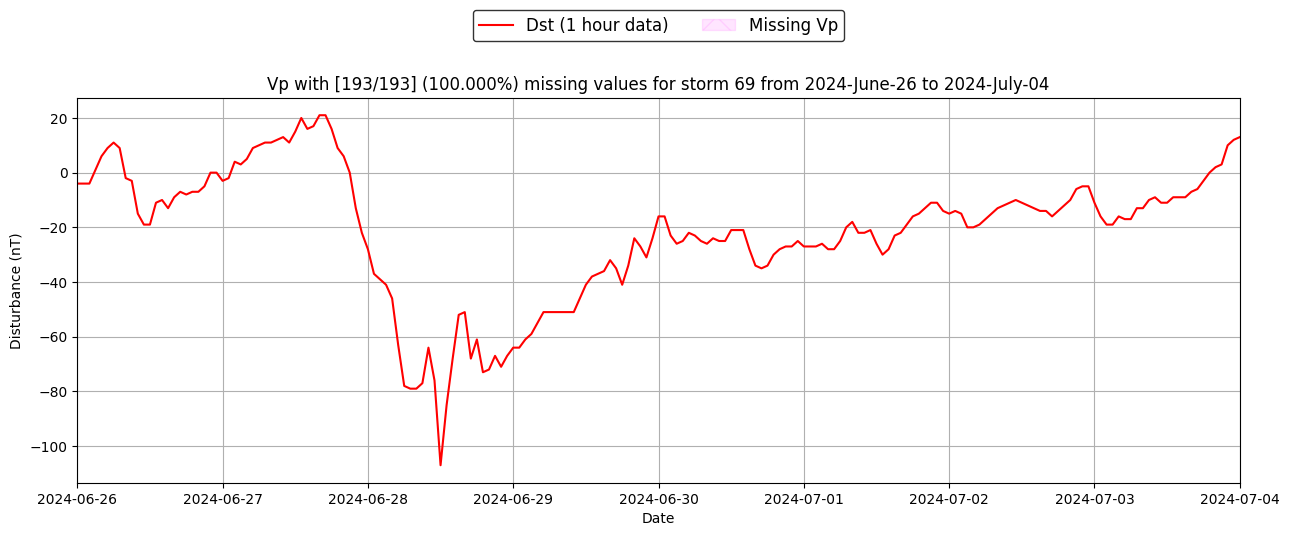

There are ACE missing values in test storm 70 from 2024 August 02 to 2024 August 19
Vp missing 409 values (100.000%)


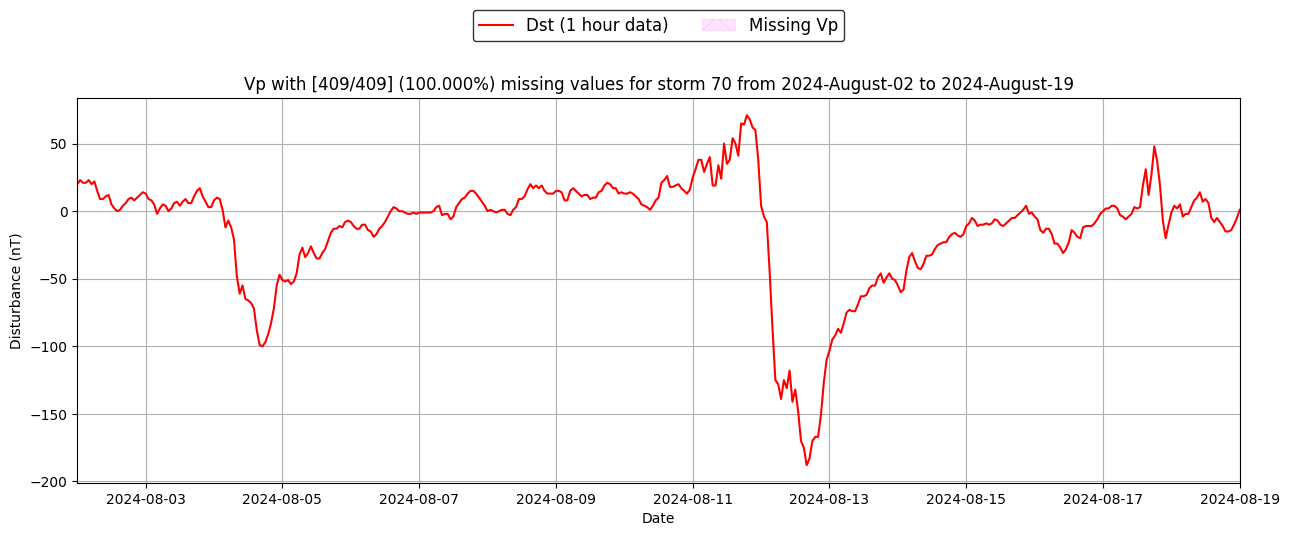

There are ACE missing values in test storm 71 from 2024 September 10 to 2024 September 23
Vp missing 313 values (100.000%)


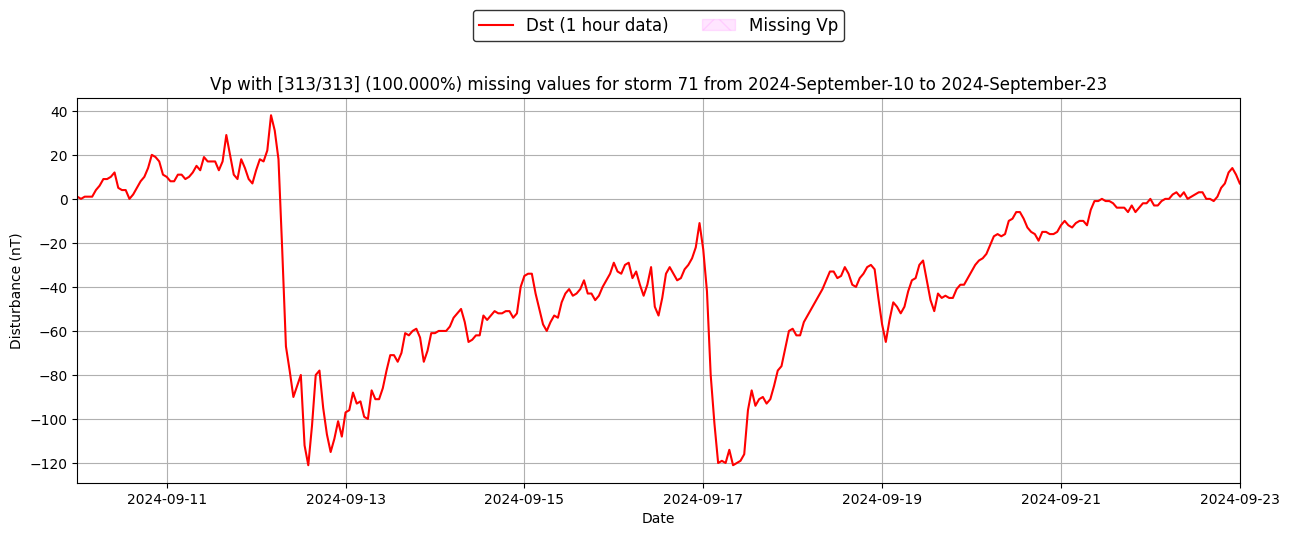

There are ACE missing values in test storm 72 from 2024 October 09 to 2024 October 14
Vp missing 121 values (100.000%)


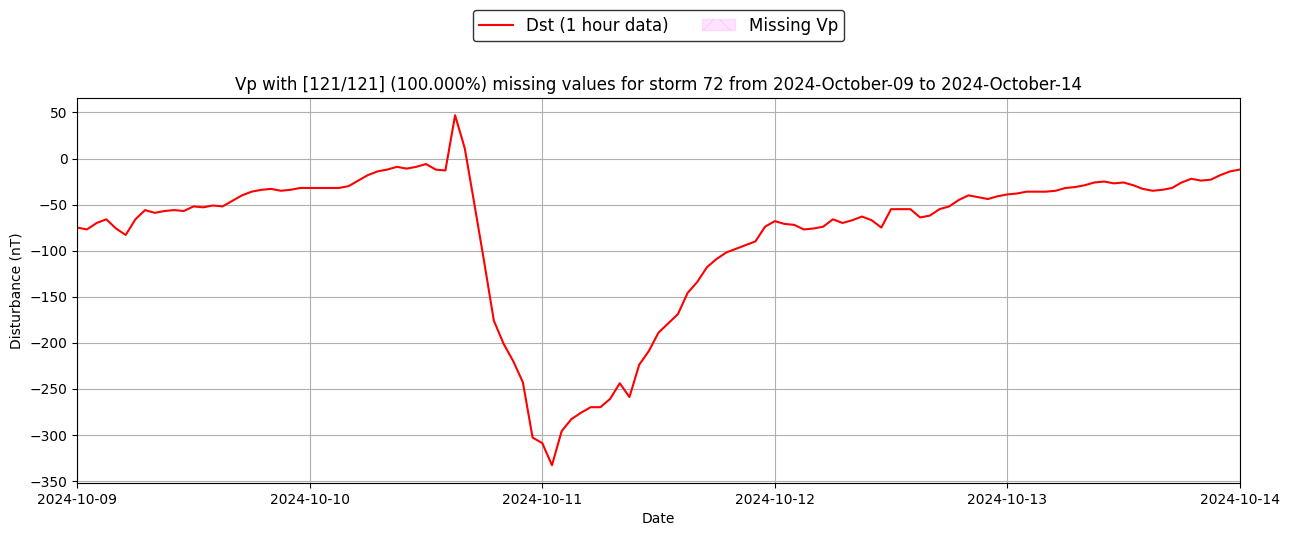

There are ACE missing values in test storm 73 from 2024 November 07 to 2024 November 15
Vp missing 193 values (100.000%)


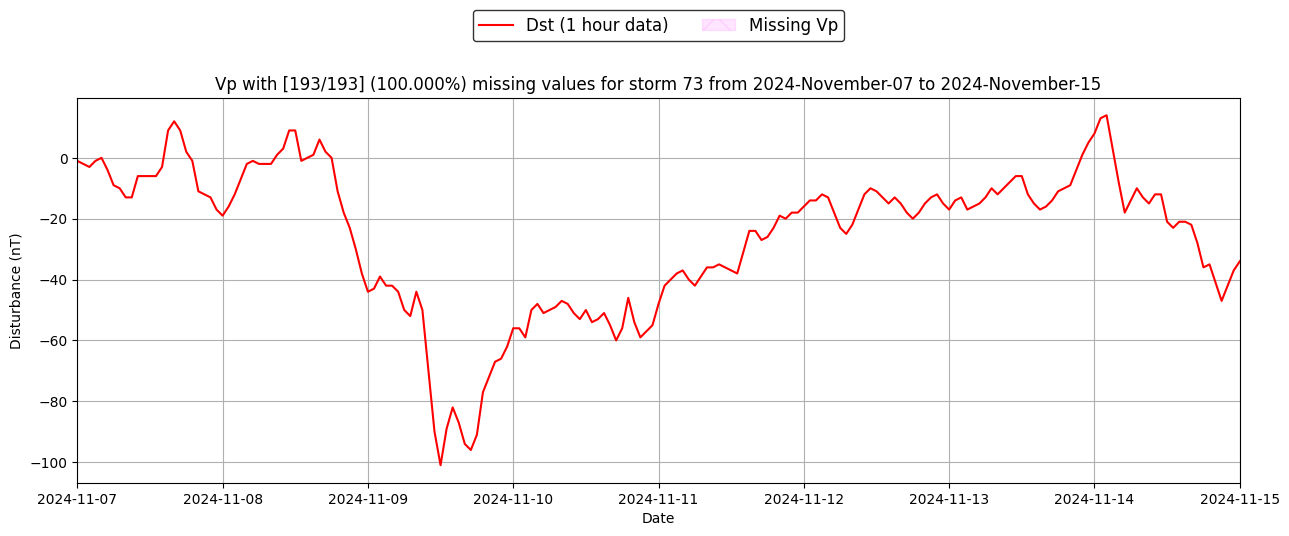

Complete ACE test storms [0/20]


In [5]:
PLOT_COMPLETE_STORMS = True
PLOT_INCOMPLETE_STORMS = True

valid_ace_test_storms = 0
for start_date, end_date, storm_index in storm_dates.TEST_STORMS_SYMBOLIC_REGRESSION:
    sd = pd.to_datetime(start_date)
    ed = pd.to_datetime(end_date)
    storm = ace_data[sd:ed].copy()
    if storm[ace_columns].isna().sum().sum() == 0:
        print(f'Test storm {storm_index} from {sd.strftime("%Y %B %d")} to {ed.strftime("%Y %B %d")} has no missing values')
        valid_ace_test_storms += 1
        
    else:
        print(f'There are ACE missing values in test storm {storm_index} from {sd.strftime("%Y %B %d")} to {ed.strftime("%Y %B %d")}')
        max_na = 0
        max_col = ''
        for col in relevant_columns:
            na_count = storm[col].isna().sum()
            if na_count > max_na:
                max_na = na_count
                max_col = col
            
        print(f'{max_col} missing {storm[max_col].isna().sum()} values ({storm[max_col].isna().sum() / len(storm[max_col]) * 100:.3f}%)')
        plot_storm(dst_kyoto, storm, max_col, sd, ed, storm_index)
            
        #col = storm[ace_columns].isna().sum().sort_values(ascending=False).index[0]
        #plot_storm(dst_kyoto, storm, col, sd, ed, storm_index)
        
print(f'Complete ACE test storms [{valid_ace_test_storms}/{len(storm_dates.TEST_STORMS_SYMBOLIC_REGRESSION)}]')